# Práctica: Construcción progresiva de una CNN para clasificación de imágenes

**Módulo:** Computer Vision  
**Tema:** Deep Learning aplicado a imagen  
**Objetivo:** aprender a construir una red neuronal convolucional paso a paso, evaluando cómo afecta cada decisión arquitectónica.

---

## Objetivos de aprendizaje

Al finalizar esta práctica, deberías ser capaz de:

- Cargar y preprocesar datasets de imágenes.
- Construir una red densa básica como baseline.
- Construir CNNs progresivamente más complejas.
- Entender el papel de `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout` y `BatchNormalization`.
- Evaluar modelos con accuracy, loss y matriz de confusión.
- Comparar el comportamiento de una CNN sobre un dataset sencillo y otro más complejo.
- Extraer conclusiones sobre sobreentrenamiento, generalización y mejoras posibles.

---

## Datasets usados

Trabajaremos con dos datasets:

1. **MNIST**: imágenes en escala de grises de dígitos manuscritos.
2. **CIFAR-10**: imágenes RGB de objetos y animales en 10 clases.

# 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

I0000 00:00:1778265489.057950    4764 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Parte A — Dataset sencillo: MNIST

MNIST contiene imágenes de dígitos manuscritos del 0 al 9.

Cada imagen tiene tamaño **28 × 28 píxeles** y está en **escala de grises**.

# 2. Carga de MNIST

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


## Preguntas

1. ¿Qué tamaño tienen las imágenes?
2. ¿Cuántas imágenes hay para entrenamiento?
3. ¿Cuántas imágenes hay para test?
4. ¿Cuántas clases hay?
5. ¿Las imágenes son en color o en escala de grises?

# 3. Visualización inicial

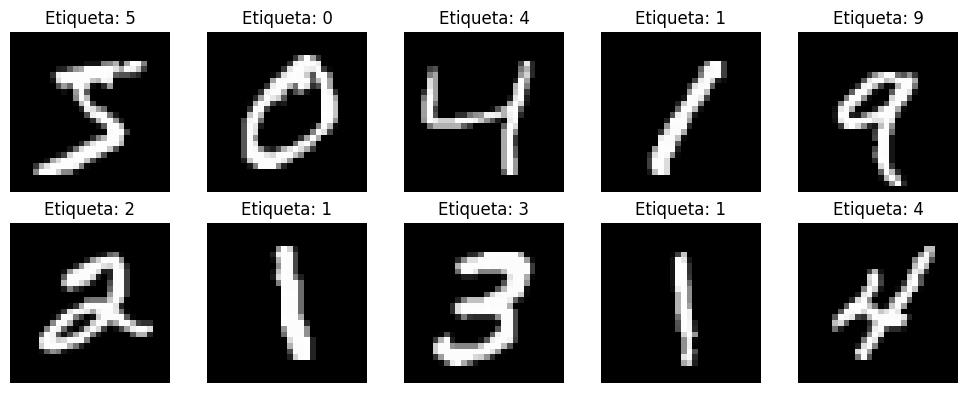

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Preprocesado de MNIST

Normalizamos las imágenes dividiendo entre 255 para que los valores queden en el rango `[0, 1]`.

Además, añadimos una dimensión de canal, ya que Keras espera tensores con forma:

`(n_imágenes, alto, ancho, canales)`

In [5]:
X_train_mnist = X_train.astype("float32") / 255.0
X_test_mnist = X_test.astype("float32") / 255.0

X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

y_train_mnist_cat = to_categorical(y_train, 10)
y_test_mnist_cat = to_categorical(y_test, 10)

print("X_train_mnist:", X_train_mnist.shape)
print("X_test_mnist:", X_test_mnist.shape)
print("y_train_mnist_cat:", y_train_mnist_cat.shape)
print("y_test_mnist_cat:", y_test_mnist_cat.shape)

X_train_mnist: (60000, 28, 28, 1)
X_test_mnist: (10000, 28, 28, 1)
y_train_mnist_cat: (60000, 10)
y_test_mnist_cat: (10000, 10)


## Preguntas

1. ¿Por qué dividimos entre 255?
2. ¿Por qué añadimos una dimensión final con valor 1?
3. ¿Qué hace `to_categorical`?
4. ¿Por qué la capa de salida tendrá 10 neuronas?

# 5. Funciones auxiliares

Usaremos una función para representar las curvas de entrenamiento y otra para guardar resultados.

In [6]:
def plot_history(history, title="Entrenamiento"):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
results = []

# Modelo 1 — Red densa simple, sin convoluciones

## Enunciado

Antes de usar convoluciones, construiremos una red neuronal densa básica.

Este modelo servirá como **baseline**.

In [8]:
model_1 = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

/root/projects/computer_vision_oscar/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1778265682.670149    4764 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_1 = model_1.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9063 - loss: 0.3362 - val_accuracy: 0.9467 - val_loss: 0.1846
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9541 - loss: 0.1554 - val_accuracy: 0.9555 - val_loss: 0.1487
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9679 - loss: 0.1100 - val_accuracy: 0.9653 - val_loss: 0.1157
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9762 - loss: 0.0831 - val_accuracy: 0.9688 - val_loss: 0.1030
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0656 - val_accuracy: 0.9702 - val_loss: 0.0970
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9847 - loss: 0.0519 - val_accuracy: 0.9712 - val_loss: 0.0963
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9876 - loss: 0.0422 - val_accuracy: 0.9741 - val_loss: 0.0842
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.

In [10]:
test_loss_1, test_acc_1 = model_1.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 1 - Dense baseline",
    "tecnicas": "Flatten + Dense",
    "test_accuracy": test_acc_1,
    "test_loss": test_loss_1
})

print("Accuracy test:", test_acc_1)
print("Loss test:", test_loss_1)

Accuracy test: 0.9787999987602234
Loss test: 0.07267129421234131


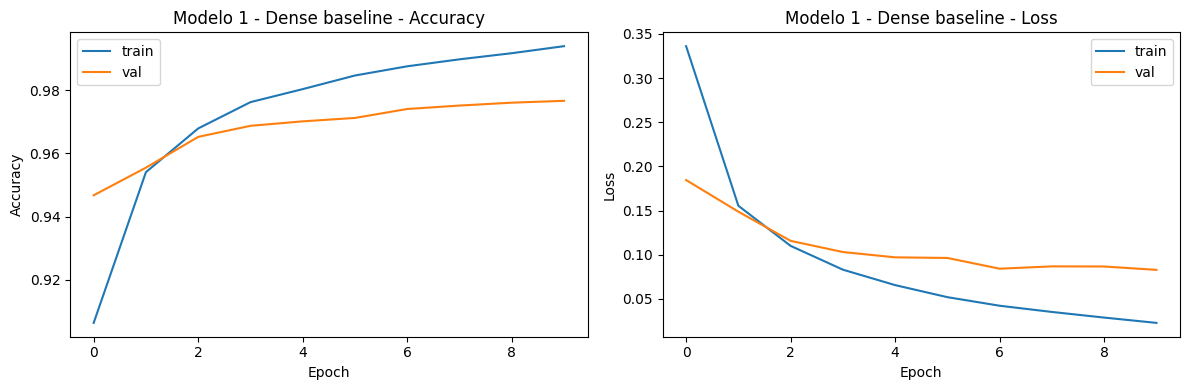

In [11]:
plot_history(history_1, "Modelo 1 - Dense baseline")

## Análisis solicitado

Responde:

1. ¿Qué accuracy obtiene el modelo?
2. ¿Hay diferencia entre accuracy de entrenamiento y validación?
3. ¿Este modelo aprovecha la estructura espacial de la imagen?
4. ¿Qué limitación tiene usar solo `Flatten + Dense`?

# Modelo 2 — Primera CNN sencilla

## Enunciado

Ahora construiremos una CNN mínima con una capa convolucional y una capa de pooling.

In [12]:
model_2 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

/root/projects/computer_vision_oscar/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_2 = model_2.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9319 - loss: 0.2333 - val_accuracy: 0.9762 - val_loss: 0.0856
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9779 - loss: 0.0738 - val_accuracy: 0.9800 - val_loss: 0.0678
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9840 - loss: 0.0520 - val_accuracy: 0.9824 - val_loss: 0.0593
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9883 - loss: 0.0390 - val_accuracy: 0.9828 - val_loss: 0.0596
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9906 - loss: 0.0302 - val_accuracy: 0.9818 - val_loss: 0.0620
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9927 - loss: 0.0236 - val_accuracy: 0.9837 - val_loss: 0.0542
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9947 - loss: 0.0173 - val_accuracy: 0.9846 - val_loss: 0.0552
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.

In [14]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 2 - CNN sencilla",
    "tecnicas": "1 Conv2D + MaxPooling",
    "test_accuracy": test_acc_2,
    "test_loss": test_loss_2
})

print("Accuracy test:", test_acc_2)
print("Loss test:", test_loss_2)

Accuracy test: 0.9833999872207642
Loss test: 0.05920546129345894


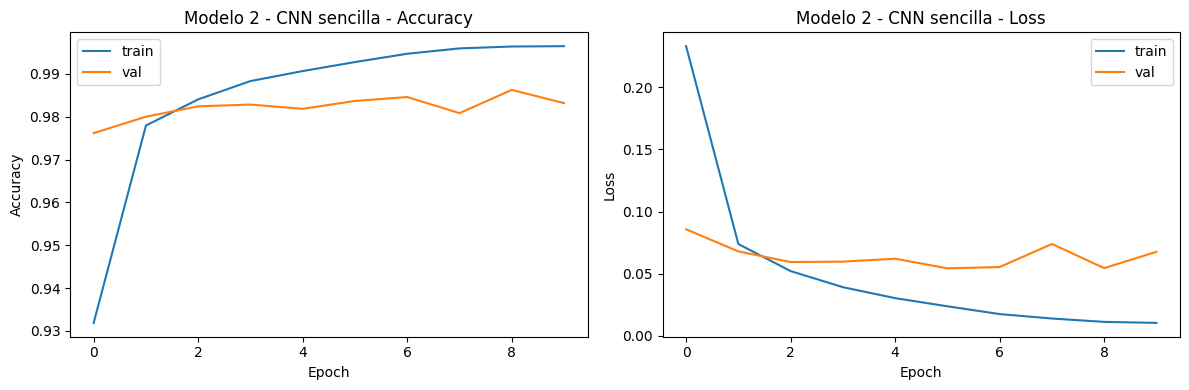

In [15]:
plot_history(history_2, "Modelo 2 - CNN sencilla")

## Preguntas

1. ¿Mejora respecto al modelo denso?
2. ¿Qué aprende la capa `Conv2D`?
3. ¿Qué efecto tiene `MaxPooling2D`?
4. ¿Qué ocurre con el tamaño de la imagen después de la convolución y el pooling?
5. ¿Por qué una CNN suele funcionar mejor en imágenes que una red densa simple?

# Modelo 3 — CNN más profunda

## Enunciado

Añade más bloques convolucionales para que el modelo aprenda características más complejas.

In [16]:
model_3 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_3 = model_3.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9448 - loss: 0.1827 - val_accuracy: 0.9832 - val_loss: 0.0607
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9834 - loss: 0.0549 - val_accuracy: 0.9833 - val_loss: 0.0542
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9883 - loss: 0.0376 - val_accuracy: 0.9891 - val_loss: 0.0387
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9914 - loss: 0.0278 - val_accuracy: 0.9881 - val_loss: 0.0410
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9932 - loss: 0.0206 - val_accuracy: 0.9890 - val_loss: 0.0360
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9877 - val_loss: 0.0442
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9957 - loss: 0.0129 - val_accuracy: 0.9887 - val_loss: 0.0432
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accur

In [18]:
test_loss_3, test_acc_3 = model_3.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 3 - CNN profunda",
    "tecnicas": "2 Conv2D + MaxPooling",
    "test_accuracy": test_acc_3,
    "test_loss": test_loss_3
})

print("Accuracy test:", test_acc_3)
print("Loss test:", test_loss_3)

Accuracy test: 0.9902999997138977
Loss test: 0.034052830189466476


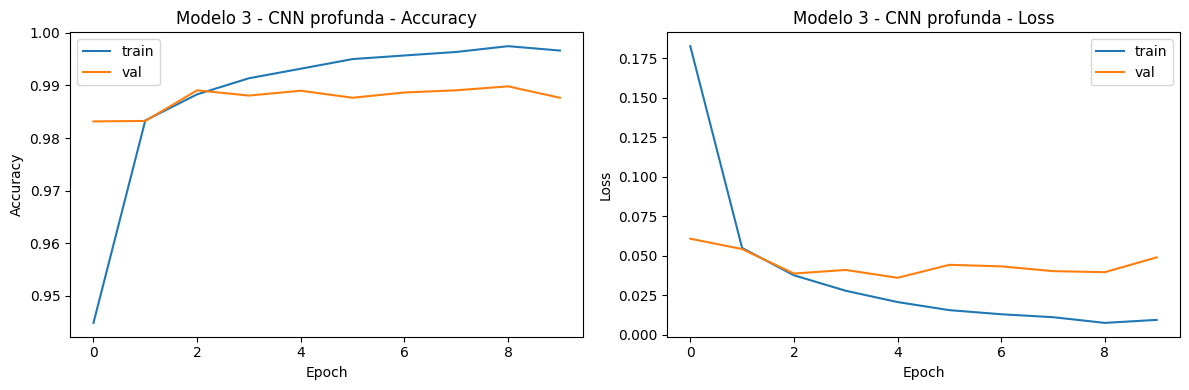

In [19]:
plot_history(history_3, "Modelo 3 - CNN profunda")

## Análisis

Compara el modelo 1, 2 y 3.

Preguntas:

1. ¿Mejora el rendimiento al añadir más convoluciones?
2. ¿El modelo aprende más rápido?
3. ¿Hay señales de sobreentrenamiento?
4. ¿Qué modelo elegirías hasta ahora y por qué?

# Modelo 4 — CNN con Dropout

## Enunciado

Ahora añade `Dropout` para reducir el sobreentrenamiento.

In [20]:
model_4 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_4 = model_4.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9100 - loss: 0.2938 - val_accuracy: 0.9783 - val_loss: 0.0761
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9692 - loss: 0.1034 - val_accuracy: 0.9845 - val_loss: 0.0532
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9781 - loss: 0.0743 - val_accuracy: 0.9873 - val_loss: 0.0446
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9824 - loss: 0.0580 - val_accuracy: 0.9882 - val_loss: 0.0431
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9844 - loss: 0.0507 - val_accuracy: 0.9893 - val_loss: 0.0391
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9866 - loss: 0.0448 - val_accuracy: 0.9902 - val_loss: 0.0367
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9906 - val_loss: 0.0382
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9892 - loss: 0.0347 - val_accura

In [22]:
test_loss_4, test_acc_4 = model_4.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 4 - CNN + Dropout",
    "tecnicas": "2 Conv2D + Dropout",
    "test_accuracy": test_acc_4,
    "test_loss": test_loss_4
})

print("Accuracy test:", test_acc_4)
print("Loss test:", test_loss_4)

Accuracy test: 0.9908000230789185
Loss test: 0.024731701239943504


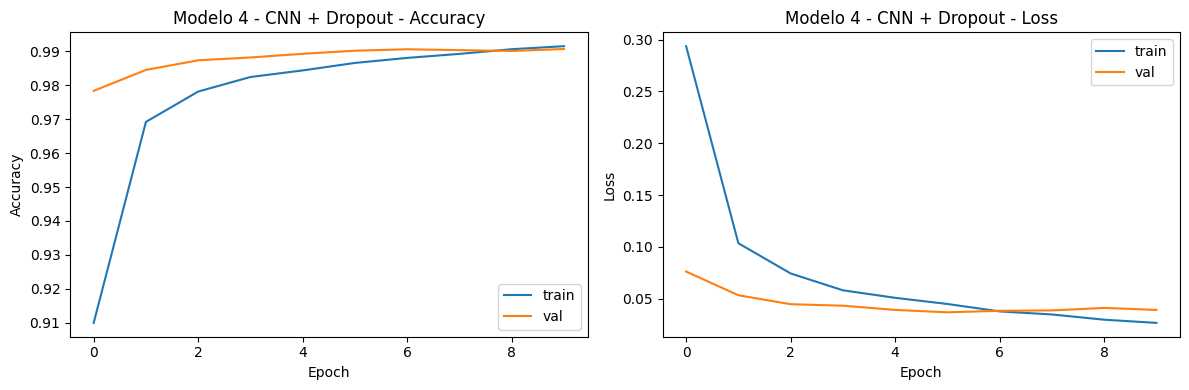

In [23]:
plot_history(history_4, "Modelo 4 - CNN + Dropout")

## Preguntas

1. ¿Qué hace `Dropout(0.5)`?
2. ¿El accuracy de entrenamiento baja?
3. ¿El accuracy de validación mejora?
4. ¿Qué es más importante: tener mayor accuracy en entrenamiento o mejor generalización?

# Modelo 5 — CNN con Batch Normalization

## Enunciado

Añade `BatchNormalization` después de las convoluciones.

In [24]:
model_5 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_5.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [25]:
history_5 = model_5.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9257 - loss: 0.2479 - val_accuracy: 0.9838 - val_loss: 0.0556
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9694 - loss: 0.1013 - val_accuracy: 0.9880 - val_loss: 0.0456
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9777 - loss: 0.0753 - val_accuracy: 0.9857 - val_loss: 0.0541
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9819 - loss: 0.0608 - val_accuracy: 0.9864 - val_loss: 0.0483
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9846 - loss: 0.0503 - val_accuracy: 0.9888 - val_loss: 0.0452
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9854 - loss: 0.0470 - val_accuracy: 0.9907 - val_loss: 0.0361
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9878 - loss: 0.0400 - val_accuracy: 0.9912 - val_loss: 0.0359
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9886 - loss: 0.0364 - 

In [26]:
test_loss_5, test_acc_5 = model_5.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 5 - CNN + BN + Dropout",
    "tecnicas": "Conv2D + BatchNorm + Dropout",
    "test_accuracy": test_acc_5,
    "test_loss": test_loss_5
})

print("Accuracy test:", test_acc_5)
print("Loss test:", test_loss_5)

Accuracy test: 0.9919000267982483
Loss test: 0.031457338482141495


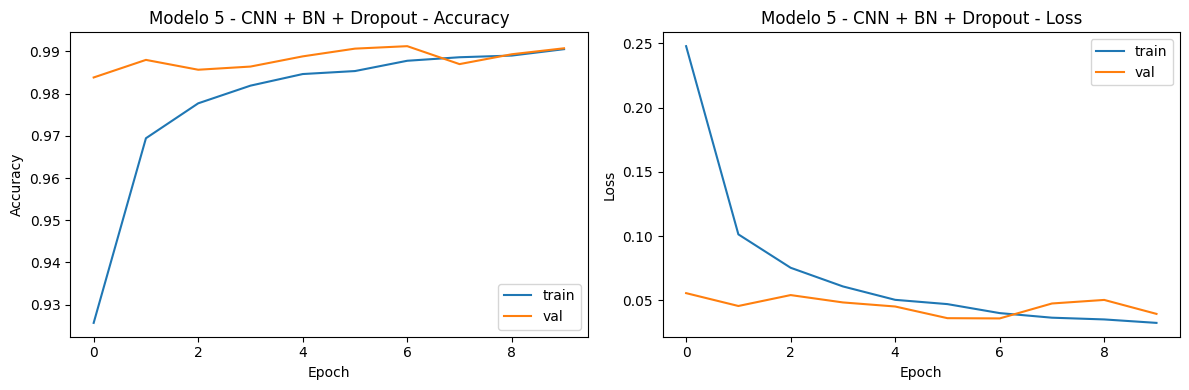

In [27]:
plot_history(history_5, "Modelo 5 - CNN + BN + Dropout")

## Preguntas

1. ¿Qué efecto tiene `BatchNormalization`?
2. ¿El entrenamiento parece más estable?
3. ¿Mejora el resultado final?
4. ¿Batch Normalization sustituye a Dropout o pueden combinarse?

# Comparativa MNIST

In [28]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results[df_results["dataset"] == "MNIST"]

,dataset,modelo,tecnicas,test_accuracy,test_loss
0,MNIST,Modelo 1 - Dense baseline,Flatten + Dense,0.9788,0.072671
1,MNIST,Modelo 2 - CNN sencilla,1 Conv2D + MaxPooling,0.9834,0.059205
2,MNIST,Modelo 3 - CNN profunda,2 Conv2D + MaxPooling,0.9903,0.034053
3,MNIST,Modelo 4 - CNN + Dropout,2 Conv2D + Dropout,0.9908,0.024732
4,MNIST,Modelo 5 - CNN + BN + Dropout,Conv2D + BatchNorm + Dropout,0.9919,0.031457


# Parte B — Dataset más difícil: CIFAR-10

CIFAR-10 contiene imágenes RGB de 32 × 32 píxeles.

Clases:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

# 6. Carga de CIFAR-10

In [29]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train_cifar:", X_train_cifar.shape)
print("y_train_cifar:", y_train_cifar.shape)
print("X_test_cifar:", X_test_cifar.shape)
print("y_test_cifar:", y_test_cifar.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 133s 1us/step
X_train_cifar: (50000, 32, 32, 3)
y_train_cifar: (50000, 1)
X_test_cifar: (10000, 32, 32, 3)
y_test_cifar: (10000, 1)


/root/projects/computer_vision_oscar/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


# 7. Visualización de CIFAR-10

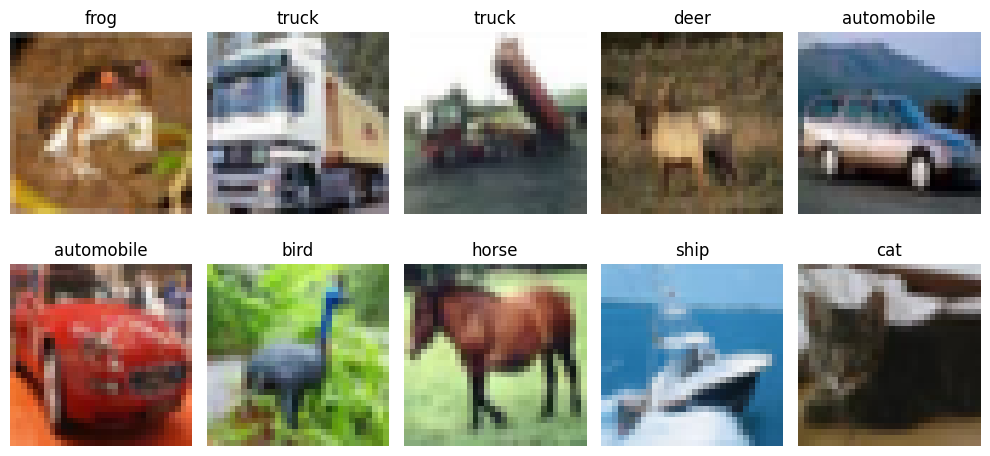

In [31]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_cifar[i])
    plt.title(class_names[int(y_train_cifar[i][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Preprocesado de CIFAR-10

In [32]:
X_train_cifar = X_train_cifar.astype("float32") / 255.0
X_test_cifar = X_test_cifar.astype("float32") / 255.0

y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

print("X_train_cifar:", X_train_cifar.shape)
print("X_test_cifar:", X_test_cifar.shape)
print("y_train_cifar_cat:", y_train_cifar_cat.shape)
print("y_test_cifar_cat:", y_test_cifar_cat.shape)

X_train_cifar: (50000, 32, 32, 3)
X_test_cifar: (10000, 32, 32, 3)
y_train_cifar_cat: (50000, 10)
y_test_cifar_cat: (10000, 10)


# Modelo 6 — CNN básica para CIFAR-10

## Enunciado

Construye una CNN sencilla para CIFAR-10.

In [33]:
model_6 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_6.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_6.summary()

/root/projects/computer_vision_oscar/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_6 = model_6.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4476 - loss: 1.5346 - val_accuracy: 0.5471 - val_loss: 1.2908
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5863 - loss: 1.1742 - val_accuracy: 0.5881 - val_loss: 1.1697
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6347 - loss: 1.0442 - val_accuracy: 0.6419 - val_loss: 1.0403
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6688 - loss: 0.9480 - val_accuracy: 0.6489 - val_loss: 1.0179
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6913 - loss: 0.8828 - val_accuracy: 0.6741 - val_loss: 0.9452
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7119 - loss: 0.8279 - val_accuracy: 0.6649 - val_loss: 0.9626
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7273 - loss: 0.7796 - val_accuracy: 0.6864 - val_loss: 0.9110
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7484 - loss: 0.7230 - 

In [35]:
test_loss_6, test_acc_6 = model_6.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 6 - CNN básica",
    "tecnicas": "2 Conv2D + MaxPooling",
    "test_accuracy": test_acc_6,
    "test_loss": test_loss_6
})

print("Accuracy test:", test_acc_6)
print("Loss test:", test_loss_6)

Accuracy test: 0.6798999905586243
Loss test: 1.3368122577667236


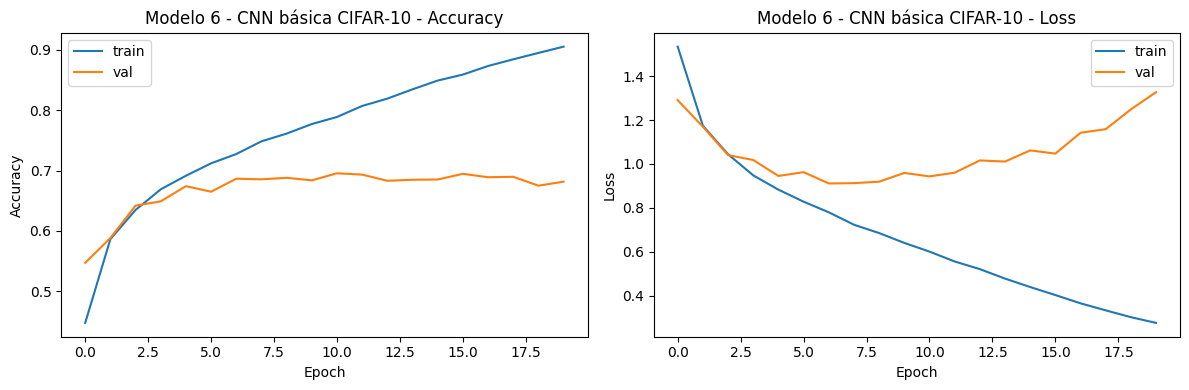

In [36]:
plot_history(history_6, "Modelo 6 - CNN básica CIFAR-10")

## Preguntas

1. ¿Obtiene peor resultado que en MNIST?
2. ¿Por qué CIFAR-10 es más difícil?
3. ¿Influye que las imágenes sean RGB?
4. ¿Qué clases parecen más difíciles de distinguir?

# Modelo 7 — CNN mejorada para CIFAR-10

## Enunciado

Construye una CNN más profunda con Dropout y Batch Normalization.

In [37]:
model_7 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_7.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [38]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [39]:
history_7 = model_7.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 133ms/step - accuracy: 0.4377 - loss: 1.6613 - val_accuracy: 0.5423 - val_loss: 1.2599
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.6130 - loss: 1.0905 - val_accuracy: 0.6583 - val_loss: 0.9791
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.6754 - loss: 0.9221 - val_accuracy: 0.7227 - val_loss: 0.7703
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.7087 - loss: 0.8242 - val_accuracy: 0.6637 - val_loss: 0.9627
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.7361 - loss: 0.7598 - val_accuracy: 0.7313 - val_loss: 0.7612
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.7551 - loss: 0.7049 - val_accuracy: 0.7433 - val_loss: 0.7734
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.7702 - loss: 0.6601 - val_accuracy: 0.7673 - val_loss: 0.7031
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.7824 - loss: 0

In [40]:
test_loss_7, test_acc_7 = model_7.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 7 - CNN mejorada",
    "tecnicas": "CNN profunda + BN + Dropout + EarlyStopping",
    "test_accuracy": test_acc_7,
    "test_loss": test_loss_7
})

print("Accuracy test:", test_acc_7)
print("Loss test:", test_loss_7)

Accuracy test: 0.8238999843597412
Loss test: 0.5163677334785461


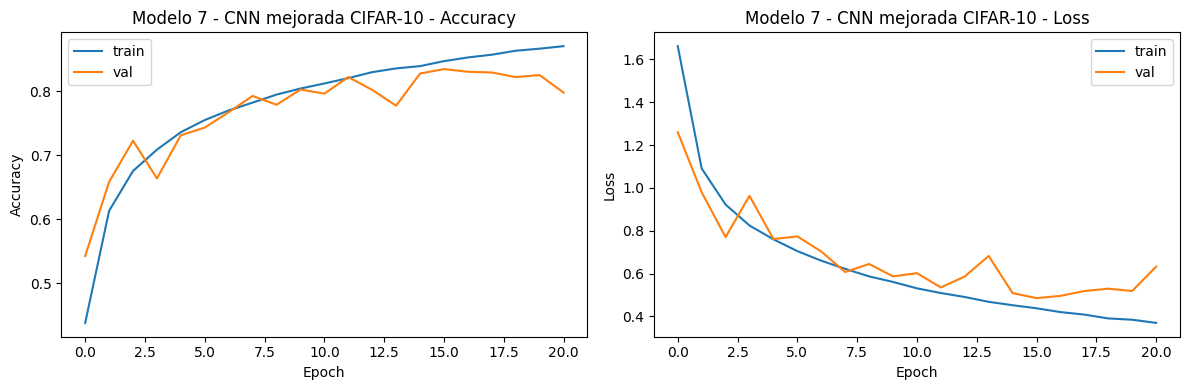

In [41]:
plot_history(history_7, "Modelo 7 - CNN mejorada CIFAR-10")

## Preguntas

1. ¿Mejora respecto al modelo anterior?
2. ¿Qué aporta `padding="same"`?
3. ¿Por qué se usan más filtros en capas profundas?
4. ¿Qué función cumple `EarlyStopping`?
5. ¿Se observa sobreentrenamiento?
6. ¿Dónde se nota más el efecto del Dropout?

# Modelo 8 — Data Augmentation

## Enunciado

Ahora añade aumento de datos para mejorar la generalización.

In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_cifar)

In [43]:
model_8 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_8.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_8.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [44]:
early_stop_aug = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [45]:
history_8 = model_8.fit(
    datagen.flow(X_train_cifar, y_train_cifar_cat, batch_size=64),
    validation_data=(X_test_cifar, y_test_cifar_cat),
    epochs=50,
    callbacks=[early_stop_aug]
)

Epoch 1/50


I0000 00:00:1778268848.399734    4764 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 161ms/step - accuracy: 0.4127 - loss: 1.7211 - val_accuracy: 0.5512 - val_loss: 1.2721
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 171ms/step - accuracy: 0.5795 - loss: 1.1798 - val_accuracy: 0.6187 - val_loss: 1.1267
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 166ms/step - accuracy: 0.6355 - loss: 1.0287 - val_accuracy: 0.6456 - val_loss: 1.0240
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 132s 168ms/step - accuracy: 0.6680 - loss: 0.9434 - val_accuracy: 0.6571 - val_loss: 0.9817
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 132s 168ms/step - accuracy: 0.6888 - loss: 0.8894 - val_accuracy: 0.6965 - val_loss: 0.8986
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 166ms/step - accuracy: 0.7068 - loss: 0.8415 - val_accuracy: 0.7463 - val_loss: 0.7463
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 165ms/step - accuracy: 0.7194 - loss: 0.8027 - val_accuracy: 0.7645 - val_loss: 0.6693
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 164ms/step - accuracy: 0.7308 - loss: 0.77

In [46]:
test_loss_8, test_acc_8 = model_8.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 8 - CNN + Data Augmentation",
    "tecnicas": "CNN profunda + BN + Dropout + Augmentation",
    "test_accuracy": test_acc_8,
    "test_loss": test_loss_8
})

print("Accuracy test:", test_acc_8)
print("Loss test:", test_loss_8)

Accuracy test: 0.7824000120162964
Loss test: 0.6388267874717712


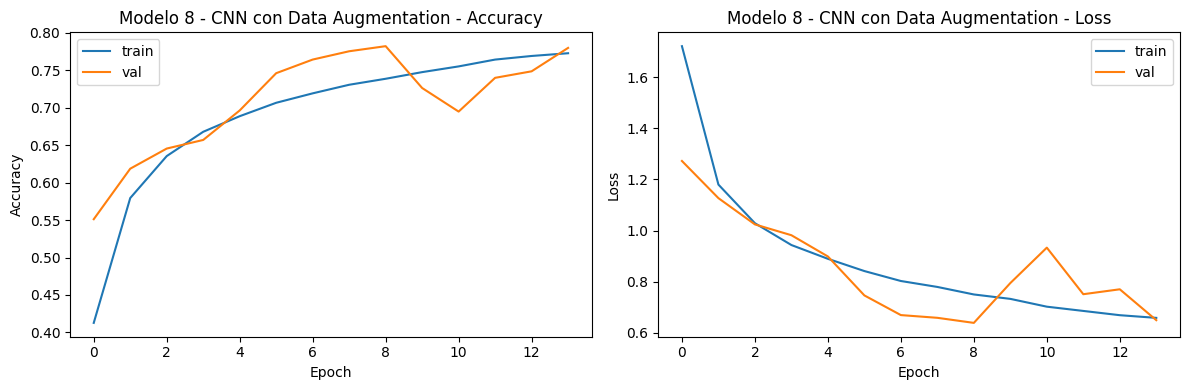

In [47]:
plot_history(history_8, "Modelo 8 - CNN con Data Augmentation")

## Preguntas

1. ¿Qué transformaciones se están aplicando a las imágenes?
2. ¿Por qué data augmentation ayuda a generalizar?
3. ¿Tiene sentido aplicar `horizontal_flip=True` en todas las clases?
4. ¿Qué ocurriría si aplicásemos rotaciones demasiado grandes?
5. ¿El modelo tarda más en entrenar?
6. ¿Mejora el resultado en test?

# 9. Matriz de confusión

Puedes elegir el modelo que quieras analizar. Por defecto, usaremos `model_7`.

Si has entrenado `model_8` y quieres analizarlo, cambia `model_to_analyze = model_7` por `model_to_analyze = model_8`.

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


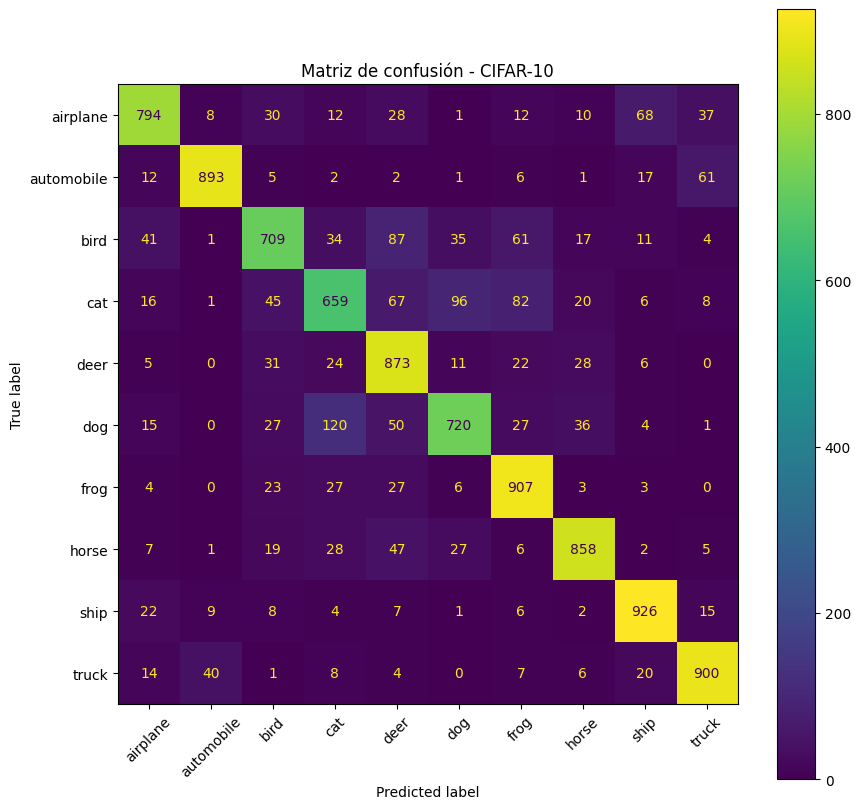

In [48]:
model_to_analyze = model_7

y_pred_probs = model_to_analyze.predict(X_test_cifar)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_cifar.flatten()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - CIFAR-10")
plt.show()

## Preguntas sobre errores

1. ¿Qué clases se confunden más?
2. ¿Tiene sentido visualmente esa confusión?
3. ¿Se confunden más animales con animales o vehículos con vehículos?
4. ¿Qué harías para mejorar esas clases?
5. ¿Crees que el modelo está aprendiendo forma, color, textura o contexto?

# 10. Tabla final de resultados

In [49]:
df_results = pd.DataFrame(results)
df_results

,dataset,modelo,tecnicas,test_accuracy,test_loss
0,MNIST,Modelo 1 - Dense baseline,Flatten + Dense,0.9788,0.072671
1,MNIST,Modelo 2 - CNN sencilla,1 Conv2D + MaxPooling,0.9834,0.059205
2,MNIST,Modelo 3 - CNN profunda,2 Conv2D + MaxPooling,0.9903,0.034053
3,MNIST,Modelo 4 - CNN + Dropout,2 Conv2D + Dropout,0.9908,0.024732
4,MNIST,Modelo 5 - CNN + BN + Dropout,Conv2D + BatchNorm + Dropout,0.9919,0.031457
5,CIFAR-10,Modelo 6 - CNN básica,2 Conv2D + MaxPooling,0.6799,1.336812
6,CIFAR-10,Modelo 7 - CNN mejorada,CNN profunda + BN + Dropout + EarlyStopping,0.8239,0.516368
7,CIFAR-10,Modelo 8 - CNN + Data Augmentation,CNN profunda + BN + Dropout + Augmentation,0.7824,0.638827


# 11. Entregable del alumno

El alumno deberá entregar este notebook completado con:

## Apartado 1 — MNIST

- Carga y visualización del dataset.
- Modelo denso simple.
- Primera CNN.
- CNN más profunda.
- CNN con Dropout.
- CNN con Batch Normalization.
- Tabla comparativa de resultados.
- Conclusiones.

## Apartado 2 — CIFAR-10

- Carga y visualización del dataset.
- CNN básica.
- CNN mejorada.
- CNN con data augmentation.
- Matriz de confusión.
- Análisis de clases más difíciles.
- Conclusiones finales.

# 12. Solución orientativa

## Conclusiones esperadas para MNIST

Una red densa simple puede funcionar razonablemente bien porque MNIST es un dataset sencillo. Sin embargo, no aprovecha explícitamente la estructura espacial de la imagen.

Al introducir convoluciones, el modelo suele mejorar porque aprende patrones locales: bordes, curvas, trazos y combinaciones de trazos.

El pooling reduce el tamaño de los mapas de características y hace el modelo más robusto ante pequeños desplazamientos.

Una CNN más profunda suele mejorar los resultados, aunque en MNIST no siempre se aprecia una diferencia enorme porque el problema ya es bastante fácil.

Dropout puede reducir el sobreentrenamiento, aunque en modelos pequeños puede bajar ligeramente el accuracy de entrenamiento.

Batch Normalization puede hacer el entrenamiento más estable.

---

## Conclusiones esperadas para CIFAR-10

CIFAR-10 es bastante más difícil que MNIST porque:

- Las imágenes son en color.
- Hay fondos variados.
- Los objetos son pequeños.
- Hay más variabilidad intra-clase.
- Algunas clases son visualmente parecidas.

Una CNN básica suele quedarse corta.

Al añadir más bloques convolucionales, Batch Normalization, Dropout y data augmentation, el modelo suele generalizar mejor.

Es normal que clases como `cat`, `dog`, `deer` y `horse` se confundan entre sí.

También pueden confundirse `automobile` y `truck`, o `airplane` y `ship` en algunas imágenes.

# 13. Preguntas finales de reflexión

1. ¿Qué diferencia principal hay entre una red densa y una CNN?
2. ¿Por qué las primeras capas convolucionales suelen aprender bordes o texturas simples?
3. ¿Por qué las capas profundas aprenden patrones más abstractos?
4. ¿Qué problema intenta solucionar Dropout?
5. ¿Qué problema intenta solucionar Batch Normalization?
6. ¿Qué diferencia hay entre mejorar el accuracy de entrenamiento y mejorar el accuracy de test?
7. ¿Por qué un modelo más grande no siempre es mejor?
8. ¿Qué harías si tu modelo sobreentrena?
9. ¿Qué harías si tu modelo no aprende suficiente?
10. ¿Cuándo tendría sentido usar transfer learning?

# 14. Extensión opcional

Prueba alguna de estas modificaciones:

- Cambiar el número de filtros: 16, 32, 64, 128.
- Cambiar el tamaño del kernel: `(3,3)` frente a `(5,5)`.
- Cambiar el valor de Dropout: `0.25`, `0.5`, `0.7`.
- Cambiar el optimizador: `adam`, `sgd`, `rmsprop`.
- Añadir más épocas.
- Usar `GlobalAveragePooling2D` en lugar de `Flatten`.
- Comparar el número de parámetros de cada modelo.
- Probar transfer learning con `MobileNetV2`.

# 15. Rúbrica sugerida

| Criterio | Peso |
|---|---:|
| Carga, visualización y preprocesado correcto | 15% |
| Construcción progresiva de modelos | 25% |
| Evaluación con métricas y gráficas | 20% |
| Comparación entre MNIST y CIFAR-10 | 15% |
| Análisis crítico de resultados | 20% |
| Limpieza y claridad del notebook | 5% |